# Notebook 16 — Construcción del Índice Territorial Integrado para Centros de Procesamiento de Datos (IIT-CPD)

## Finalidad

En este notebook construimos el IIT-CPD como un marco multicriterio de apoyo a la decisión. Definimos las variables utilizadas, su tratamiento como beneficio, coste o criterio contextual, la normalización, los indicadores parciales, los escenarios de ponderación, los rankings y los análisis de sensibilidad y Pareto.

Partimos de la matriz original preparada en el Notebook 12, formada por 22 territorios comparables y 21 variables seleccionadas. También incorporamos los perfiles territoriales obtenidos en el Notebook 15 como información complementaria para interpretar los resultados.

## Principio metodológico central

Los análisis realizados en los Notebooks 13, 14 y 15 mediante Isolation Forest, PCA y K-Means permiten comprender la estructura de los datos, detectar comportamientos singulares y construir perfiles territoriales. Sin embargo, estos resultados no determinan automáticamente los pesos ni la posición de los territorios en el IIT-CPD.

Los pesos representan distintas prioridades de decisión, mientras que las cargas del PCA explican la estructura de varianza de los datos. Por este motivo mantenemos ambos conceptos separados.

Incorporamos los seis perfiles obtenidos mediante K-Means como apoyo interpretativo. No los usamos para calcular las puntuaciones ni para modificar los rankings.

## Matriz de diseño actualizada

* Trabajamos con los **22 territorios NUTS 2 comparables** de España peninsular y Portugal continental.
* Partimos de las **21 variables seleccionadas en el Notebook 12** y utilizamos directamente en el índice aquellas que presentan una interpretación clara y un tratamiento justificable.
* Construimos el IIT-CPD con **16 variables activas agrupadas en 8 dimensiones**: Clima, Energía solar, Territorio, Medio ambiente, Infraestructura eléctrica, Logística y digital, Capital humano e Hídrica.
* Mantenemos cinco variables como información descriptiva o de apoyo porque no presentan una dirección de preferencia suficientemente clara o porque su información ya está representada mediante otro indicador.
* Incorporamos la dimensión Hídrica mediante `hidrica_wei_area_estres_grave_pct_territorio_2019_2023`.
* Incorporamos la infraestructura eléctrica mediante los dos indicadores corregidos y comparables conservados en el Notebook 12.
* Comprobamos posteriormente la sensibilidad del ranking frente a las principales decisiones metodológicas, incluida la presencia de la dimensión eléctrica.
* Integramos los resultados finales del Notebook 15 mediante `codigo_geo`, manteniendo los perfiles K-Means como etiquetas descriptivas y no como una clasificación de idoneidad.

In [1]:
# Carga y validación de las entradas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RANDOM_STATE = 42

INPUT_DIR = Path("/kaggle/input")
OUTPUT_DIR = (
    Path.cwd()
    / "salidas_notebook_16_iitcpd"
)
OUTPUT_DIR.mkdir(exist_ok=True)


def localizar_archivo(nombre):
    rutas = list(INPUT_DIR.rglob(nombre))

    if len(rutas) != 1:
        raise FileNotFoundError(
            f"Se esperaba un único archivo "
            f"'{nombre}' y se encontraron {len(rutas)}."
        )

    return rutas[0]


# Entrada principal del Notebook 12.
DATA_PATH = localizar_archivo(
    "matriz_original_22x25.csv"
)

# Perfiles definitivos del Notebook 15.
PERFILES_PATH = localizar_archivo(
    "resultado_kmeans_con_singularidad.csv"
)

df = pd.read_csv(DATA_PATH)
perfiles_nb15 = pd.read_csv(PERFILES_PATH)

columnas_perfil_necesarias = [
    "codigo_geo",
    "cluster_id",
    "nombre_perfil",
    "distancia_centroide",
    "score_anomalia",
    "singular_modelo_base",
    "singularidad_estable",
]

correcto_01a = (
    df.shape == (22, 25)
    and len(perfiles_nb15) == 22
    and df["codigo_geo"].is_unique
    and perfiles_nb15["codigo_geo"].is_unique
    and set(df["codigo_geo"])
    == set(perfiles_nb15["codigo_geo"])
    and set(columnas_perfil_necesarias).issubset(
        perfiles_nb15.columns
    )
)

if not correcto_01a:
    raise ValueError(
        "Las entradas del Notebook 16 "
        "necesitan revisión."
    )

print("Matriz NB12:", DATA_PATH)
print("Perfiles NB15:", PERFILES_PATH)
print("Territorios:", len(df))
print("Variables analíticas:", df.shape[1] - 4)
print(
    "Perfiles territoriales:",
    perfiles_nb15["nombre_perfil"].nunique(),
)

display(
    df[
        [
            "codigo_geo",
            "nombre_territorio",
            "pais",
        ]
    ].head()
)

Matriz NB12: /kaggle/input/datasets/aemjeloy/salidas-ntb12/matriz_original_22x25.csv
Perfiles NB15: /kaggle/input/datasets/aemjeloy/salidas-15/resultado_kmeans_con_singularidad.csv
Territorios: 22
Variables analíticas: 21
Perfiles territoriales: 6


,codigo_geo,nombre_territorio,pais
0,ES11,Galicia,España
1,ES12,Principado de Asturias,España
2,ES13,Cantabria,España
3,ES21,País Vasco,España
4,ES22,Comunidad Foral de Navarra,España


## Matriz de diseño

Seleccionamos 16 de las 21 variables del Notebook 12 y las agrupamos en ocho dimensiones del IIT-CPD.

Para cada variable definimos su tratamiento como beneficio, coste o criterio contextual y su peso dentro de la dimensión correspondiente. Las cinco variables restantes las mantenemos como información de apoyo y no intervienen en el cálculo del índice.

Utilizaremos los perfiles del Notebook 15 después para interpretar los resultados, pero no modificarán las puntuaciones, los pesos ni los rankings del IIT-CPD.

In [2]:
# 01B - Matriz de diseño
criterios = [
    ("Clima", "temperatura_media_2m_c", "coste", 0.50),
    ("Clima", "punto_rocio_medio_c", "coste", 0.50),
    ("Energia_solar", "pvgis_produccion_anual_kwh_kwp", "beneficio", 0.60),
    ("Energia_solar", "pvgis_coef_variacion_mensual", "coste", 0.40),
    ("Territorio", "corine_compat_media_0_3", "beneficio", 1.00),
    ("Medio_ambiente", "ambiental_penalizacion_media_0_1", "coste", 1.00),
    ("Electrica", "electrica_densidad_alta_tension_km_1000km2", "beneficio", 0.50),
    ("Electrica", "electrica_densidad_subestaciones_1000km2", "beneficio", 0.50),
    ("Logistica_digital", "logistica_road_alta_capacidad_km_por_1000km2", "beneficio", 0.20),
    ("Logistica_digital", "logistica_places_n_por_1000km2", "beneficio", 0.20),
    ("Logistica_digital", "digital_torres_mastiles_1000km2", "beneficio", 0.20),
    ("Logistica_digital", "digital_data_centers_osm_n", "beneficio", 0.20),
    ("Logistica_digital", "digital_exchanges_centrales_telecom_1000km2", "beneficio", 0.20),
    ("Capital_humano", "densidad_poblacion", "contextual_triangular", 0.40),
    ("Capital_humano", "nivel_formativo_terciario", "beneficio", 0.60),
    ("Hidrica", "hidrica_wei_area_estres_grave_pct_territorio_2019_2023", "coste", 1.00),
]

matriz_df = pd.DataFrame(
    criterios,
    columns=["dimension", "variable", "tratamiento", "peso"],
)
DIMENSIONES_ACTIVAS = matriz_df["dimension"].unique().tolist()
VARIABLES_DESCRIPTIVAS = [
    v for v in df.columns[4:]
    if v not in matriz_df["variable"].tolist()
]
assert matriz_df["variable"].isin(df.columns).all()
assert np.allclose(
    matriz_df.groupby("dimension")["peso"].sum(),
    1,
)
assert (len(matriz_df), len(DIMENSIONES_ACTIVAS)) == (16, 8)
matriz_df.to_csv(
    OUTPUT_DIR / "matriz_diseno_iitcpd.csv",
    index=False,
)

print("Variables activas: 16")
print("Dimensiones activas: 8")
print("Variables de apoyo:", len(VARIABLES_DESCRIPTIVAS))

matriz_df

Variables activas: 16
Dimensiones activas: 8
Variables de apoyo: 5


,dimension,variable,tratamiento,peso
0,Clima,temperatura_media_2m_c,coste,0.5
1,Clima,punto_rocio_medio_c,coste,0.5
2,Energia_solar,pvgis_produccion_anual_kwh_kwp,beneficio,0.6
3,Energia_solar,pvgis_coef_variacion_mensual,coste,0.4
4,Territorio,corine_compat_media_0_3,beneficio,1.0
5,Medio_ambiente,ambiental_penalizacion_media_0_1,coste,1.0
6,Electrica,electrica_densidad_alta_tension_km_1000km2,beneficio,0.5
7,Electrica,electrica_densidad_subestaciones_1000km2,beneficio,0.5
8,Logistica_digital,logistica_road_alta_capacidad_km_por_1000km2,beneficio,0.2
9,Logistica_digital,logistica_places_n_por_1000km2,beneficio,0.2


## Normalización de las variables

Transformamos las variables a una escala común entre 0 y 1, donde un valor mayor representa una situación más favorable para instalar un CPD.

Aplicamos tres tratamientos:

* **Beneficio:** los valores más altos reciben mayor puntuación.
* **Coste:** los valores más bajos reciben mayor puntuación.
* **Contextual triangular:** la puntuación máxima se sitúa en la mediana y disminuye hacia los valores extremos.


In [3]:
# 02A - Funciones de normalización
def normalizar_beneficio(serie):
    rango = serie.max() - serie.min()
    if rango == 0:
        return pd.Series(1.0, index=serie.index)
    return (serie - serie.min()) / rango

def normalizar_coste(serie):
    return 1 - normalizar_beneficio(serie)

def normalizar_triangular(serie):
    puntos = [
        serie.min(),
        serie.median(),
        serie.max(),
    ]
    valores = [0, 1, 0]
    return pd.Series(
        np.interp(serie, puntos, valores),
        index=serie.index,
    )

TRATAMIENTOS = {
    "beneficio": normalizar_beneficio,
    "coste": normalizar_coste,
    "contextual_triangular": normalizar_triangular,
}

print("Tratamientos:", ", ".join(TRATAMIENTOS))


Tratamientos: beneficio, coste, contextual_triangular


## Indicadores por dimensión

Normalizamos las 16 variables según su tratamiento y calculamos cada dimensión mediante la media ponderada de sus criterios.

El resultado será una tabla con ocho indicadores entre 0 y 1 para cada territorio. Un valor mayor representará una situación más favorable.


In [4]:
# Indicadores por dimensión
def construir_indicadores(datos, diseno=matriz_df):
    indicadores = datos[
        ["codigo_geo", "nombre_territorio", "pais"]
    ].copy()
    detalle = datos[["codigo_geo"]].copy()
    
    for dimension, criterios in diseno.groupby(
        "dimension",
        sort=False,
    ):
        indicadores[dimension] = 0.0
        for _, criterio in criterios.iterrows():
            variable = criterio["variable"]
            score = TRATAMIENTOS[
                criterio["tratamiento"]
            ](datos[variable])
            detalle[f"{variable}__score"] = score
            indicadores[dimension] += (
                criterio["peso"] * score
            )
    return indicadores, detalle

indicadores_df, detalle_norm_df = construir_indicadores(df)
valores = indicadores_df[DIMENSIONES_ACTIVAS]
assert indicadores_df.shape == (22, 11)
assert not valores.isna().any().any()
assert valores.apply(
    lambda columna: columna.between(0, 1).all()
).all()
indicadores_df.to_csv(
    OUTPUT_DIR / "indicadores_parciales_dimension.csv",
    index=False,
)

print("Territorios:", len(indicadores_df))
print("Dimensiones calculadas:", len(DIMENSIONES_ACTIVAS))

display(indicadores_df.round(3))

Territorios: 22
Dimensiones calculadas: 8


,codigo_geo,nombre_territorio,pais,Clima,Energia_solar,Territorio,Medio_ambiente,Electrica,Logistica_digital,Capital_humano,Hidrica
0,ES11,Galicia,España,0.664,0.099,0.118,0.447,0.216,0.318,0.718,0.987
1,ES12,Principado de Asturias,España,0.801,0.247,0.000,0.147,0.275,0.178,0.774,1.000
2,ES13,Cantabria,España,0.783,0.030,0.072,0.000,0.220,0.169,0.860,0.960
3,ES21,País Vasco,España,0.670,0.061,0.194,0.171,0.392,0.224,0.944,0.928
4,ES22,Comunidad Foral de Navarra,España,0.762,0.252,0.415,0.141,0.022,0.091,0.729,0.831
5,ES23,La Rioja,España,0.948,0.307,0.307,0.175,0.041,0.066,0.568,0.809
6,ES24,Aragón,España,0.824,0.707,0.455,0.181,0.105,0.066,0.381,0.778
7,ES30,Comunidad de Madrid,España,0.762,0.750,0.548,0.001,0.391,0.333,0.696,1.000
8,ES41,Castilla y León,España,0.961,0.471,0.527,0.260,0.120,0.085,0.379,0.671
9,ES42,Castilla-La Mancha,España,0.706,0.552,0.623,0.388,0.070,0.011,0.230,0.562


## Escenarios de ponderación

Definimos cuatro escenarios sobre las **ocho dimensiones activas** del IIT-CPD: Equilibrado, Energético, Ambiental y Tecnológico.

Los escenarios representan distintas prioridades e incorporan las dimensiones Eléctrica e Hídrica. En todos comprobamos que aparecen las mismas ocho dimensiones y que sus pesos suman 1.


In [5]:
# Escenarios de ponderación
dimensiones = [
    "Clima",
    "Energia_solar",
    "Territorio",
    "Medio_ambiente",
    "Electrica",
    "Logistica_digital",
    "Capital_humano",
    "Hidrica",
]
pesos_df = pd.DataFrame(
    [
        [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
        [0.20, 0.20, 0.05, 0.05, 0.25, 0.10, 0.05, 0.10],
        [0.15, 0.10, 0.15, 0.25, 0.05, 0.05, 0.05, 0.20],
        [0.05, 0.05, 0.05, 0.05, 0.25, 0.35, 0.15, 0.05],
    ],
    index=[
        "Equilibrado",
        "Energetico",
        "Ambiental",
        "Tecnologico",
    ],
    columns=dimensiones,
).T
assert dimensiones == DIMENSIONES_ACTIVAS
assert np.allclose(pesos_df.sum(), 1)

ESCENARIOS = pesos_df.to_dict()
pesos_df.to_csv(
    OUTPUT_DIR / "pesos_escenarios.csv",
    index_label="dimension",
)

print("Escenarios: 4 | Dimensiones: 8")

pesos_df

Escenarios: 4 | Dimensiones: 8


,Equilibrado,Energetico,Ambiental,Tecnologico
Clima,0.125,0.20,0.15,0.05
Energia_solar,0.125,0.20,0.10,0.05
Territorio,0.125,0.05,0.15,0.05
Medio_ambiente,0.125,0.05,0.25,0.05
Electrica,0.125,0.25,0.05,0.25
Logistica_digital,0.125,0.10,0.05,0.35
Capital_humano,0.125,0.05,0.05,0.15
Hidrica,0.125,0.10,0.20,0.05


## Cálculo del IIT-CPD y rankings

Calculamos la puntuación de cada territorio mediante la suma ponderada de sus ocho indicadores:

$$
IIT\text{-}CPD = \sum_{d=1}^{8} w_d \cdot I_d
$$

Después ordenamos los 22 territorios de mayor a menor puntuación. El puesto 1 representa el territorio mejor valorado en cada escenario.


In [6]:
# IIT-CPD y rankings
puntuaciones = (
    indicadores_df[DIMENSIONES_ACTIVAS]
    .dot(pesos_df)
    .add_prefix("IIT-CPD_")
)

resultado_iitcpd = pd.concat(
    [
        indicadores_df[
            ["codigo_geo", "nombre_territorio", "pais"]
        ],
        puntuaciones,
    ],
    axis=1,
)
for escenario in pesos_df.columns:
    resultado_iitcpd[f"ranking_{escenario}"] = (
        puntuaciones[f"IIT-CPD_{escenario}"]
        .rank(ascending=False, method="min")
        .astype(int)
    )
assert puntuaciones.apply(
    lambda x: x.between(0, 1).all()
).all()
resultado_iitcpd.to_csv(
    OUTPUT_DIR / "iitcpd_resultados_escenarios.csv",
    index=False,
)

print("Territorios: 22 | Escenarios: 4")

display(
    resultado_iitcpd.sort_values(
        "ranking_Equilibrado"
    ).round(3)
)

Territorios: 22 | Escenarios: 4


,codigo_geo,nombre_territorio,pais,IIT-CPD_Equilibrado,IIT-CPD_Energetico,IIT-CPD_Ambiental,IIT-CPD_Tecnologico,ranking_Equilibrado,ranking_Energetico,ranking_Ambiental,ranking_Tecnologico
18,PT1A,Grande Lisboa,Portugal,0.630,0.624,0.616,0.700,1,1,2,1
15,PT11,Norte,Portugal,0.566,0.568,0.618,0.498,2,3,1,3
7,ES30,Comunidad de Madrid,España,0.560,0.596,0.543,0.472,3,2,4,4
19,PT1B,Península de Setúbal,Portugal,0.475,0.493,0.434,0.542,4,5,16,2
21,PT1D,Oeste e Vale do Tejo,Portugal,0.469,0.401,0.580,0.352,5,12,3,9
11,ES51,Cataluña,España,0.466,0.495,0.451,0.369,6,4,12,7
14,ES62,Región de Murcia,España,0.452,0.427,0.469,0.296,7,9,10,12
3,ES21,País Vasco,España,0.448,0.425,0.442,0.419,8,10,15,5
0,ES11,Galicia,España,0.446,0.401,0.499,0.389,9,15,6,6
6,ES24,Aragón,España,0.437,0.468,0.491,0.254,10,6,8,17


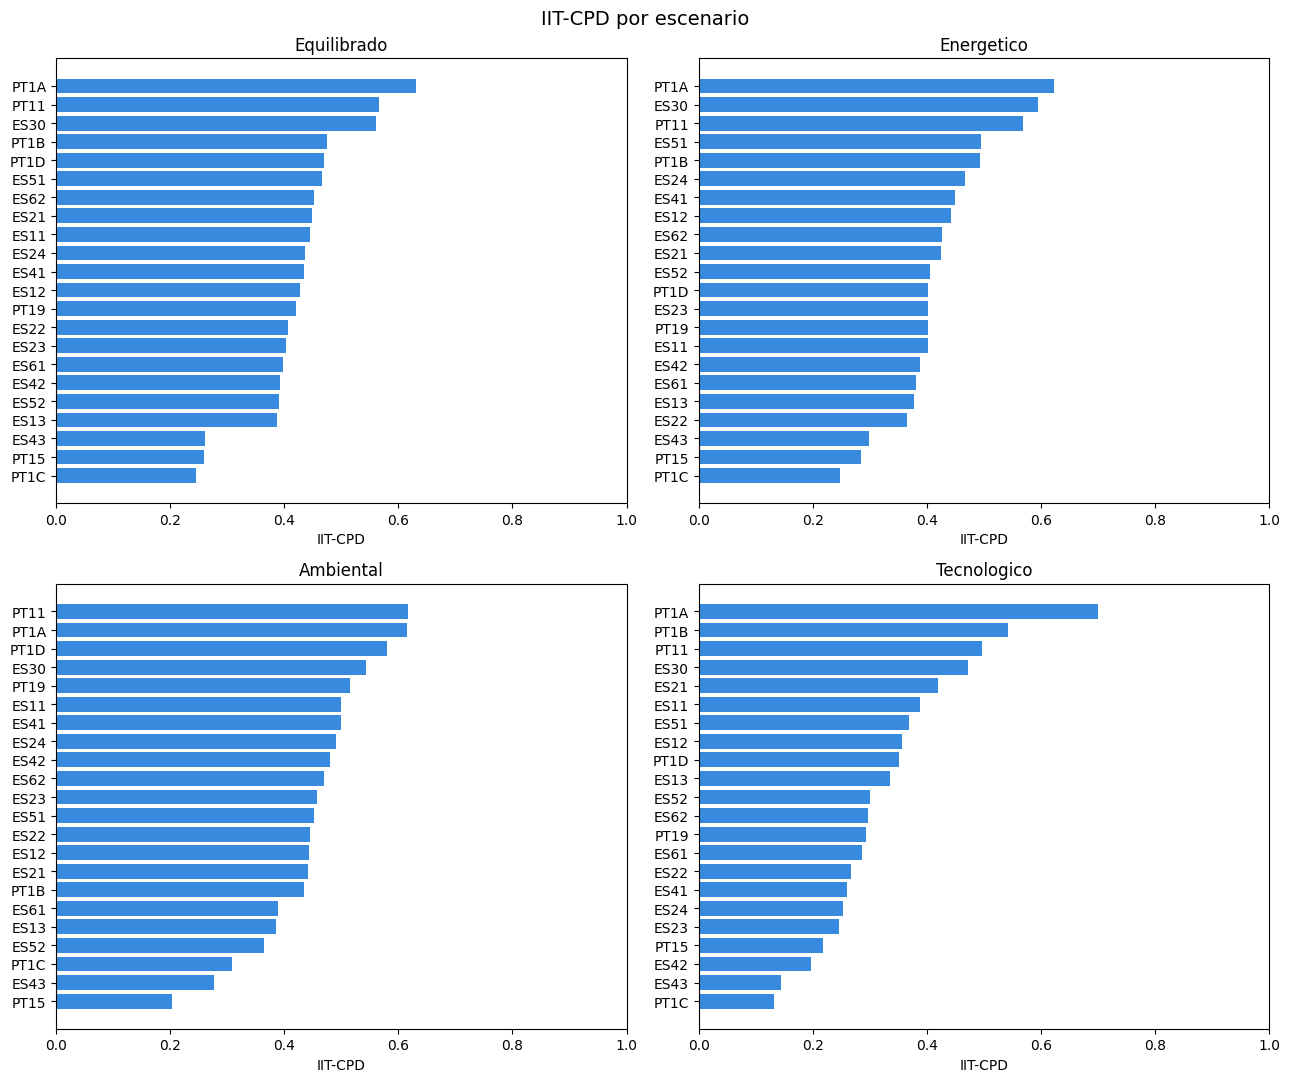

In [7]:
# Comparación visual de escenarios
fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 11),
)
for ax, escenario in zip(
    axes.flat,
    pesos_df.columns,
):
    columna = f"IIT-CPD_{escenario}"
    datos = resultado_iitcpd.sort_values(columna)
    ax.barh(
        datos["codigo_geo"],
        datos[columna],
        color="#378ADD",
    )
    ax.set_title(escenario)
    ax.set_xlabel("IIT-CPD")
    ax.set_xlim(0, 1)
fig.suptitle(
    "IIT-CPD por escenario",
    fontsize=14,
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "iitcpd_por_escenario.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()



## Estabilidad de los rankings

Comparamos los cuatro rankings mediante la correlación de Spearman.

Un valor próximo a 1 indica que dos escenarios ordenan los territorios de forma similar. Un valor menor indica que el cambio de prioridades modifica más la clasificación.


In [8]:
# Estabilidad entre escenarios
from itertools import combinations
from scipy.stats import spearmanr

filas = []
for escenario_1, escenario_2 in combinations(
    pesos_df.columns,
    2,
):
    rho = spearmanr(
        resultado_iitcpd[f"ranking_{escenario_1}"],
        resultado_iitcpd[f"ranking_{escenario_2}"],
    )[0]
    filas.append([
        escenario_1,
        escenario_2,
        round(rho, 3),
    ])
correlaciones_df = pd.DataFrame(
    filas,
    columns=[
        "escenario_1",
        "escenario_2",
        "spearman_rho",
    ],
)
correlaciones_df.to_csv(
    OUTPUT_DIR / "correlacion_rankings_escenarios.csv",
    index=False,
)

print("Comparaciones:", len(correlaciones_df))

correlaciones_df

Comparaciones: 6


,escenario_1,escenario_2,spearman_rho
0,Equilibrado,Energetico,0.870
1,Equilibrado,Ambiental,0.756
2,Equilibrado,Tecnologico,0.823
3,Energetico,Ambiental,0.626
4,Energetico,Tecnologico,0.727
5,Ambiental,Tecnologico,0.462


### Interpretación de la estabilidad

Las correlaciones de Spearman se encuentran entre **0,462 y 0,870**.

El escenario Equilibrado mantiene una relación alta con el Energético, el Ambiental y el Tecnológico. La menor similitud aparece entre los escenarios Ambiental y Tecnológico.

Los resultados muestran que el orden general se mantiene en parte, pero cambia cuando modificamos las prioridades. Por tanto, utilizamos los escenarios como alternativas de decisión y no como un único ranking definitivo.


## Análisis de sensibilidad

Comprobamos la estabilidad del ranking del escenario Equilibrado mediante cinco contrastes de sensibilidad:

1. Densidad de población con tratamiento triangular frente a su exclusión.
2. Densidad de población con tratamiento triangular frente a su consideración como criterio de beneficio.
3. Normalización min-max frente a la alternativa robusta P5-P95.
4. Inclusión frente a exclusión de la dimensión Capital humano.
5. Inclusión frente a exclusión de la dimensión Eléctrica.

En todos los casos comparamos los rankings mediante la correlación de Spearman.

Estas pruebas no sustituyen la configuración principal del IIT-CPD, sino que permiten evaluar hasta qué punto los resultados dependen de estas decisiones metodológicas.


In [9]:
# Sensibilidad de la densidad
def calcular_equilibrado(diseno):
    indicadores, _ = construir_indicadores(df, diseno)
    return indicadores[DIMENSIONES_ACTIVAS].mean(axis=1)

# Alternativa sin densidad
sin_densidad = matriz_df[
    matriz_df["variable"] != "densidad_poblacion"
].copy()
sin_densidad.loc[
    sin_densidad["variable"] == "nivel_formativo_terciario",
    "peso",
] = 1.0

# Alternativa con densidad como beneficio
densidad_beneficio = matriz_df.copy()
densidad_beneficio.loc[
    densidad_beneficio["variable"] == "densidad_poblacion",
    "tratamiento",
] = "beneficio"
sensibilidad_densidad = pd.DataFrame({
    "codigo_geo": df["codigo_geo"],
    "triangular": resultado_iitcpd["IIT-CPD_Equilibrado"],
    "exclusion": calcular_equilibrado(sin_densidad),
    "beneficio_directo": calcular_equilibrado(
        densidad_beneficio
    ),
})
for variante in [
    "triangular",
    "exclusion",
    "beneficio_directo",
]:
    sensibilidad_densidad[f"ranking_{variante}"] = (
        sensibilidad_densidad[variante]
        .rank(ascending=False)
        .astype(int)
    )
rho_exclusion = spearmanr(
    sensibilidad_densidad["ranking_triangular"],
    sensibilidad_densidad["ranking_exclusion"],
)[0]
rho_beneficio = spearmanr(
    sensibilidad_densidad["ranking_triangular"],
    sensibilidad_densidad["ranking_beneficio_directo"],
)[0]
sensibilidad_densidad.to_csv(
    OUTPUT_DIR / "sensibilidad_densidad.csv",
    index=False,
)

print(f"Triangular vs exclusión: {rho_exclusion:.3f}")
print(f"Triangular vs beneficio: {rho_beneficio:.3f}")

sensibilidad_densidad

Triangular vs exclusión: 0.924
Triangular vs beneficio: 0.940


,codigo_geo,triangular,exclusion,beneficio_directo,ranking_triangular,ranking_exclusion,ranking_beneficio_directo
0,ES11,0.445858,0.427651,0.401385,9,9,11
1,ES12,0.427640,0.410448,0.381081,12,13,14
2,ES13,0.386777,0.375954,0.340224,19,17,19
3,ES21,0.448050,0.455061,0.414210,8,8,9
4,ES22,0.405568,0.416065,0.376894,14,12,15
5,ES23,0.402606,0.400796,0.374587,15,15,16
6,ES24,0.437107,0.457486,0.430609,10,6,5
7,ES30,0.560027,0.577813,0.563006,3,2,2
8,ES41,0.434180,0.457574,0.429530,11,5,6
9,ES42,0.392802,0.402599,0.387437,17,14,13


### Sensibilidad al tratamiento de la densidad

Las correlaciones de Spearman son altas: **0,924** al excluir la densidad y **0,940** al tratarla como beneficio.

En términos globales, el ranking presenta una estabilidad alta frente a estas dos alternativas, aunque algunos territorios cambian varias posiciones.

Mantenemos el tratamiento triangular como configuración principal porque evita asumir que una densidad de población más alta es siempre más favorable para la instalación de un CPD.

In [10]:
# Sensibilidad de la normalización
def normalizar_p5_p95(serie, tratamiento):
    if tratamiento == "contextual_triangular":
        return normalizar_triangular(serie)
    p5, p95 = serie.quantile([0.05, 0.95])
    score = ((serie - p5) / (p95 - p5)).clip(0, 1)
    if tratamiento == "coste":
        score = 1 - score
    return score

scores_robustos = pd.DataFrame({
    fila.variable: normalizar_p5_p95(
        df[fila.variable],
        fila.tratamiento,
    )
    for fila in matriz_df.itertuples()
})
ind_robusto = pd.DataFrame({
    dimension: sum(
        fila.peso * scores_robustos[fila.variable]
        for fila in criterios.itertuples()
    )
    for dimension, criterios
    in matriz_df.groupby("dimension", sort=False)
})
sensibilidad_normalizacion = pd.DataFrame({
    "codigo_geo": df["codigo_geo"],
    "minmax": resultado_iitcpd["IIT-CPD_Equilibrado"],
    "robusta": ind_robusto.mean(axis=1),
})

for metodo in ["minmax", "robusta"]:
    sensibilidad_normalizacion[f"ranking_{metodo}"] = (
        sensibilidad_normalizacion[metodo]
        .rank(ascending=False)
        .astype(int)
    )
rho_norm = spearmanr(
    sensibilidad_normalizacion["ranking_minmax"],
    sensibilidad_normalizacion["ranking_robusta"],
)[0]
sensibilidad_normalizacion.to_csv(
    OUTPUT_DIR / "sensibilidad_normalizacion.csv",
    index=False,
)

print(f"Min-max vs robusta: {rho_norm:.3f}")

sensibilidad_normalizacion

Min-max vs robusta: 0.967


,codigo_geo,minmax,robusta,ranking_minmax,ranking_robusta
0,ES11,0.445858,0.486944,9,8
1,ES12,0.427640,0.462836,12,13
2,ES13,0.386777,0.400811,19,19
3,ES21,0.448050,0.472779,8,12
4,ES22,0.405568,0.439779,14,14
5,ES23,0.402606,0.425080,15,17
6,ES24,0.437107,0.474483,10,11
7,ES30,0.560027,0.631146,3,3
8,ES41,0.434180,0.475130,11,10
9,ES42,0.392802,0.434730,17,15


### Sensibilidad a la normalización

La correlación entre la normalización min-max y la alternativa robusta P5-P95 es de **0,967**.

El ranking presenta una estabilidad muy alta y los primeros puestos se mantienen. Conservamos min-max como método principal y utilizamos P5-P95 como comprobación de robustez.


In [11]:
# Sensibilidad de Capital humano
dimensiones_sin_capital = [
    d for d in DIMENSIONES_ACTIVAS
    if d != "Capital_humano"
]
sensibilidad_capital = pd.DataFrame({
    "codigo_geo": df["codigo_geo"],
    "con_capital": resultado_iitcpd[
        "IIT-CPD_Equilibrado"
    ],
    "sin_capital": indicadores_df[
        dimensiones_sin_capital
    ].mean(axis=1),
})
for variante in ["con_capital", "sin_capital"]:
    sensibilidad_capital[f"ranking_{variante}"] = (
        sensibilidad_capital[variante]
        .rank(ascending=False)
        .astype(int)
    )
rho_capital = spearmanr(
    sensibilidad_capital["ranking_con_capital"],
    sensibilidad_capital["ranking_sin_capital"],
)[0]
sensibilidad_capital.to_csv(
    OUTPUT_DIR / "sensibilidad_capital_humano.csv",
    index=False,
)

print(f"Con vs sin Capital humano: {rho_capital:.3f}")

sensibilidad_capital

Con vs sin Capital humano: 0.896


,codigo_geo,con_capital,sin_capital,ranking_con_capital,ranking_sin_capital
0,ES11,0.445858,0.407048,9,12
1,ES12,0.427640,0.378215,12,14
2,ES13,0.386777,0.319133,19,19
3,ES21,0.448050,0.377213,8,15
4,ES22,0.405568,0.359295,14,17
5,ES23,0.402606,0.378979,15,13
6,ES24,0.437107,0.445078,10,6
7,ES30,0.560027,0.540655,3,3
8,ES41,0.434180,0.442121,11,7
9,ES42,0.392802,0.415989,17,11


## Sensibilidad a Capital humano

La correlación entre los rankings con y sin Capital humano es de **0,896**.

El ranking mantiene una estabilidad global alta, aunque algunos territorios cambian varias posiciones. Conservamos esta dimensión porque incorpora información complementaria sobre el contexto demográfico y el nivel formativo terciario.


In [12]:
# Sensibilidad de la dimensión Eléctrica
dimensiones_sin_electrica = [
    d for d in DIMENSIONES_ACTIVAS
    if d != "Electrica"
]
sensibilidad_electrica = pd.DataFrame({
    "codigo_geo": df["codigo_geo"],
    "con_electrica": resultado_iitcpd[
        "IIT-CPD_Equilibrado"
    ],
    "sin_electrica": indicadores_df[
        dimensiones_sin_electrica
    ].mean(axis=1),
})

for variante in ["con_electrica", "sin_electrica"]:
    sensibilidad_electrica[f"ranking_{variante}"] = (
        sensibilidad_electrica[variante]
        .rank(ascending=False)
        .astype(int)
    )

rho_electrica = spearmanr(
    sensibilidad_electrica["ranking_con_electrica"],
    sensibilidad_electrica["ranking_sin_electrica"],
)[0]
sensibilidad_electrica.to_csv(
    OUTPUT_DIR / "sensibilidad_electrica.csv",
    index=False,
)

print(f"Con vs sin Eléctrica: {rho_electrica:.3f}")

sensibilidad_electrica

Con vs sin Eléctrica: 0.858


,codigo_geo,con_electrica,sin_electrica,ranking_con_electrica,ranking_sin_electrica
0,ES11,0.445858,0.478744,9,9
1,ES12,0.427640,0.449479,12,13
2,ES13,0.386777,0.410611,19,19
3,ES21,0.448050,0.456065,8,11
4,ES22,0.405568,0.460357,14,10
5,ES23,0.402606,0.454274,15,12
6,ES24,0.437107,0.484578,10,6
7,ES30,0.560027,0.584152,3,1
8,ES41,0.434180,0.479095,11,8
9,ES42,0.392802,0.438909,17,16


### Sensibilidad a la dimensión Eléctrica

La correlación entre los rankings con y sin la dimensión Eléctrica es de **0,858**.

El orden general mantiene una similitud alta, aunque algunos territorios cambian claramente de posición, especialmente Península de Setúbal. Conservamos esta dimensión porque la infraestructura eléctrica es un criterio relevante para instalar un CPD y disponemos de indicadores comparables en los 22 territorios.


## Resumen del análisis de sensibilidad

Reunimos los cinco contrastes realizados sobre el escenario Equilibrado: dos sobre el tratamiento de la densidad, uno sobre la normalización, uno sobre Capital humano y uno sobre la dimensión Eléctrica.

Las correlaciones de Spearman permiten comparar la estabilidad global del ranking frente a cada cambio metodológico.


In [13]:
# Resumen de sensibilidad
resumen_sensibilidad = pd.DataFrame(
    [
        ["Densidad: triangular vs exclusión", rho_exclusion],
        ["Densidad: triangular vs beneficio", rho_beneficio],
        ["Normalización: min-max vs P5-P95", rho_norm],
        ["Con vs sin Capital humano", rho_capital],
        ["Con vs sin Eléctrica", rho_electrica],
    ],
    columns=["comprobacion", "spearman_rho"],
)
resumen_sensibilidad["spearman_rho"] = (
    resumen_sensibilidad["spearman_rho"].round(3)
)
resumen_sensibilidad.to_csv(
    OUTPUT_DIR / "resumen_sensibilidad.csv",
    index=False,
)

print("Comparaciones:", len(resumen_sensibilidad))
resumen_sensibilidad

Comparaciones: 5


,comprobacion,spearman_rho
0,Densidad: triangular vs exclusión,0.924
1,Densidad: triangular vs beneficio,0.940
2,Normalización: min-max vs P5-P95,0.967
3,Con vs sin Capital humano,0.896
4,Con vs sin Eléctrica,0.858


## Frontera de Pareto empírica

Comparamos los 22 territorios mediante los ocho indicadores normalizados, sin aplicar pesos.

Un territorio domina a otro cuando obtiene una puntuación igual o superior en todas las dimensiones y es mejor en al menos una.

Calculamos el frente de Pareto, el número de territorios dominadores y el número de territorios dominados. Como analizamos ocho objetivos y solo 22 territorios, el primer frente puede ser amplio y debe interpretarse como complemento de los rankings.


In [14]:
# Frontera de Pareto
valores = indicadores_df[
    DIMENSIONES_ACTIVAS
].to_numpy()

# domina[i, j] indica si i domina a j
domina = (
    (valores[:, None] >= valores[None, :]).all(axis=2)
    & (valores[:, None] > valores[None, :]).any(axis=2)
)
numero_dominados = domina.sum(axis=1)
numero_dominadores = domina.sum(axis=0)

# Asignación de los frentes
pareto_rank = np.zeros(len(valores), dtype=int)
pendientes = np.ones(len(valores), dtype=bool)
frente = 1
while pendientes.any():
    indices = np.where(pendientes)[0]
    dominancia_actual = domina[np.ix_(indices, indices)]
    seleccionados = indices[
        dominancia_actual.sum(axis=0) == 0
    ]
    pareto_rank[seleccionados] = frente
    pendientes[seleccionados] = False
    frente += 1
pareto_df = indicadores_df[
    ["codigo_geo", "nombre_territorio", "pais"]
].copy()

pareto_df["pareto_rank"] = pareto_rank
pareto_df["es_pareto_eficiente"] = pareto_rank == 1
pareto_df["numero_dominadores"] = numero_dominadores
pareto_df["numero_dominados"] = numero_dominados
pareto_df.to_csv(
    OUTPUT_DIR / "pareto_frontera_empirica.csv",
    index=False,
)
print(
    "Territorios en el frente 1:",
    int((pareto_rank == 1).sum()),
)
print("Frentes totales:", pareto_rank.max())
pareto_df.sort_values(
    ["pareto_rank", "numero_dominadores"]
)

Territorios en el frente 1: 21
Frentes totales: 2


,codigo_geo,nombre_territorio,pais,pareto_rank,es_pareto_eficiente,numero_dominadores,numero_dominados
0,ES11,Galicia,España,1,True,0,0
1,ES12,Principado de Asturias,España,1,True,0,0
2,ES13,Cantabria,España,1,True,0,0
3,ES21,País Vasco,España,1,True,0,0
4,ES22,Comunidad Foral de Navarra,España,1,True,0,0
5,ES23,La Rioja,España,1,True,0,0
6,ES24,Aragón,España,1,True,0,1
7,ES30,Comunidad de Madrid,España,1,True,0,0
8,ES41,Castilla y León,España,1,True,0,0
9,ES42,Castilla-La Mancha,España,1,True,0,0


### Interpretación de la frontera de Pareto

El primer frente incluye **21 de los 22 territorios**. Extremadura aparece en el segundo frente porque es dominada por Aragón.

La amplitud del primer frente es esperable al comparar ocho dimensiones en una muestra pequeña. Esto muestra que la mayoría de los territorios presenta combinaciones diferentes de ventajas y desventajas.

Por tanto, Pareto se utiliza como complemento del IIT-CPD y no como un ranking único.


In [15]:
# Trazabilidad de Pareto
trazabilidad_pareto = (
    matriz_df
    .groupby("dimension", sort=False)
    .agg(
        variables_origen=(
            "variable",
            lambda x: ", ".join(x),
        )
    )
    .reset_index()
)
trazabilidad_pareto.insert(
    1,
    "orientacion",
    "mayor_es_mejor",
)
trazabilidad_pareto.to_csv(
    OUTPUT_DIR / "trazabilidad_dimensiones_pareto.csv",
    index=False,
)
print("Dimensiones documentadas:", len(trazabilidad_pareto))

trazabilidad_pareto

Dimensiones documentadas: 8


,dimension,orientacion,variables_origen
0,Clima,mayor_es_mejor,"temperatura_media_2m_c, punto_rocio_medio_c"
1,Energia_solar,mayor_es_mejor,"pvgis_produccion_anual_kwh_kwp, pvgis_coef_var..."
2,Territorio,mayor_es_mejor,corine_compat_media_0_3
3,Medio_ambiente,mayor_es_mejor,ambiental_penalizacion_media_0_1
4,Electrica,mayor_es_mejor,"electrica_densidad_alta_tension_km_1000km2, el..."
5,Logistica_digital,mayor_es_mejor,"logistica_road_alta_capacidad_km_por_1000km2, ..."
6,Capital_humano,mayor_es_mejor,"densidad_poblacion, nivel_formativo_terciario"
7,Hidrica,mayor_es_mejor,hidrica_wei_area_estres_grave_pct_territorio_2...


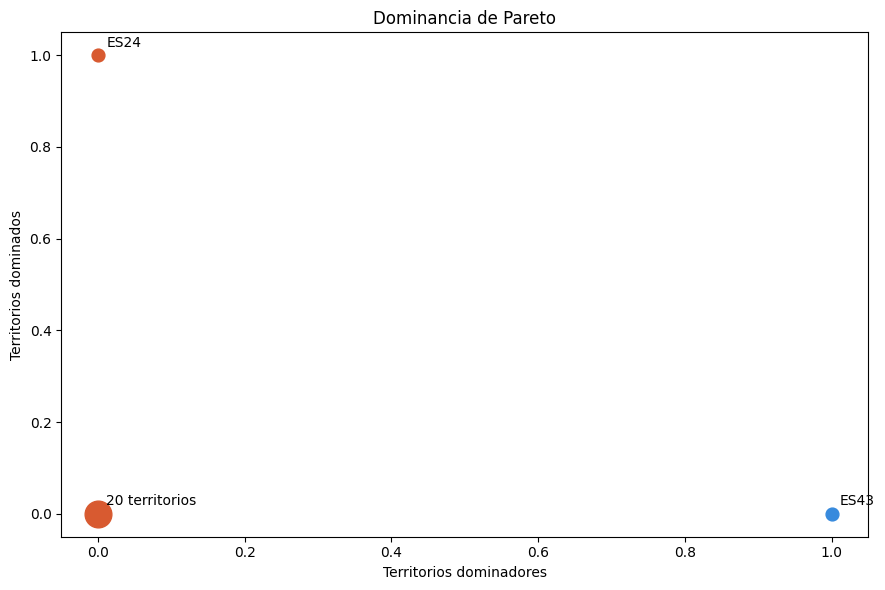

Estado 09C: correcto


In [16]:
# Gráfico de dominancia
grafico_pareto = (
    pareto_df
    .groupby(
        [
            "numero_dominadores",
            "numero_dominados",
            "pareto_rank",
        ]
    )["codigo_geo"]
    .agg(
        territorios="size",
        codigos=lambda x: ", ".join(x),
    )
    .reset_index()
)
fig, ax = plt.subplots(figsize=(9, 6))

for fila in grafico_pareto.itertuples():
    color = (
        "#D85A30"
        if fila.pareto_rank == 1
        else "#378ADD"
    )
    etiqueta = (
        f"{fila.territorios} territorios"
        if fila.territorios > 3
        else fila.codigos
    )
    ax.scatter(
        fila.numero_dominadores,
        fila.numero_dominados,
        s=70 + fila.territorios * 15,
        color=color,
    )
    ax.annotate(
        etiqueta,
        (fila.numero_dominadores, fila.numero_dominados),
        xytext=(6, 6),
        textcoords="offset points",
    )
ax.set_xlabel("Territorios dominadores")
ax.set_ylabel("Territorios dominados")
ax.set_title("Dominancia de Pareto")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "pareto_dominancia.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("Estado 09C: correcto")

### Interpretación de la dominancia

Veinte territorios no dominan ni son dominados por otro territorio.

Aragón domina a Extremadura y permanece en el primer frente. Extremadura es dominada por Aragón y queda situada en el segundo frente.

El resultado confirma que la mayoría de los territorios presenta perfiles difíciles de comparar mediante una única relación de superioridad.


In [17]:
# Líderes de escenario y Pareto
lideres = []
for escenario in pesos_df.columns:
    columna = f"IIT-CPD_{escenario}"
    fila = resultado_iitcpd.loc[
        resultado_iitcpd[columna].idxmax()
    ]
    lideres.append([
        escenario,
        fila["codigo_geo"],
        fila["nombre_territorio"],
    ])
lideres_df = pd.DataFrame(
    lideres,
    columns=[
        "escenario",
        "codigo_geo",
        "nombre_territorio",
    ],
)
cruce_top_pareto = lideres_df.merge(
    pareto_df[
        [
            "codigo_geo",
            "es_pareto_eficiente",
            "pareto_rank",
        ]
    ],
    on="codigo_geo",
    validate="many_to_one",
)
assert cruce_top_pareto[
    "es_pareto_eficiente"
].all()
cruce_top_pareto.to_csv(
    OUTPUT_DIR / "cruce_top_escenarios_pareto.csv",
    index=False,
)

print("Escenarios comprobados:", len(cruce_top_pareto))

cruce_top_pareto

Escenarios comprobados: 4


,escenario,codigo_geo,nombre_territorio,es_pareto_eficiente,pareto_rank
0,Equilibrado,PT1A,Grande Lisboa,True,1
1,Energetico,PT1A,Grande Lisboa,True,1
2,Ambiental,PT11,Norte,True,1
3,Tecnologico,PT1A,Grande Lisboa,True,1


### Cruce entre escenarios y Pareto

Grande Lisboa lidera los escenarios Equilibrado, Energético y Tecnológico. Norte lidera el escenario Ambiental.

Los dos territorios pertenecen al primer frente de Pareto. Por tanto, los líderes de los escenarios no están dominados por ningún otro territorio en las ocho dimensiones.


## Salida para Power BI

Preparamos una tabla final para facilitar la visualización de los resultados en Power BI.

La salida reúne, para los 22 territorios comparables:

* las variables activas normalizadas;
* los ocho indicadores por dimensión;
* las puntuaciones y rankings de los cuatro escenarios;
* los resultados del análisis de Pareto;
* los perfiles territoriales obtenidos en el Notebook 15 como información complementaria.

De esta forma concentramos en un único archivo los principales resultados necesarios para su posterior análisis y visualización.

In [18]:
# Salida para Power BI
columnas_pareto = [
    "codigo_geo",
    "pareto_rank",
    "es_pareto_eficiente",
    "numero_dominadores",
    "numero_dominados",
]
columnas_perfil = [
    "codigo_geo",
    "cluster_id",
    "nombre_perfil",
    "distancia_centroide",
    "score_anomalia",
    "singular_modelo_base",
    "singularidad_estable",
]
powerbi_iitcpd = (
    resultado_iitcpd
    .merge(
        indicadores_df,
        on=["codigo_geo", "nombre_territorio", "pais"],
        validate="one_to_one",
    )
    .merge(
        detalle_norm_df,
        on="codigo_geo",
        validate="one_to_one",
    )
    .merge(
        pareto_df[columnas_pareto],
        on="codigo_geo",
        validate="one_to_one",
    )
    .merge(
        perfiles_nb15[columnas_perfil],
        on="codigo_geo",
        validate="one_to_one",
    )
)
assert len(powerbi_iitcpd) == 22
assert not powerbi_iitcpd["codigo_geo"].duplicated().any()
assert not powerbi_iitcpd["nombre_perfil"].isna().any()
powerbi_iitcpd.to_csv(
    OUTPUT_DIR / "iitcpd_powerbi.csv",
    index=False,
)

print(
    "Filas:", powerbi_iitcpd.shape[0],
    "| Columnas:", powerbi_iitcpd.shape[1],
)

powerbi_iitcpd.head()

Filas: 22 | Columnas: 45


,codigo_geo,nombre_territorio,pais,IIT-CPD_Equilibrado,IIT-CPD_Energetico,IIT-CPD_Ambiental,IIT-CPD_Tecnologico,ranking_Equilibrado,ranking_Energetico,ranking_Ambiental,...,pareto_rank,es_pareto_eficiente,numero_dominadores,numero_dominados,cluster_id,nombre_perfil,distancia_centroide,score_anomalia,singular_modelo_base,singularidad_estable
0,ES11,Galicia,España,0.445858,0.401208,0.499023,0.388637,9,15,6,...,1,True,0,0,2,Húmedo y de menor potencial solar,2.060635,-0.036186,False,False
1,ES12,Principado de Asturias,España,0.427640,0.442142,0.442785,0.356839,12,8,14,...,1,True,0,0,2,Húmedo y de menor potencial solar,0.784842,-0.041994,False,False
2,ES13,Cantabria,España,0.386777,0.377035,0.385787,0.335293,19,18,18,...,1,True,0,0,2,Húmedo y de menor potencial solar,0.625230,-0.033956,False,False
3,ES21,País Vasco,España,0.448050,0.424824,0.442151,0.419260,8,10,15,...,1,True,0,0,2,Húmedo y de menor potencial solar,1.916054,-0.028339,False,False
4,ES22,Comunidad Foral de Navarra,España,0.405568,0.364900,0.445440,0.267020,14,19,13,...,1,True,0,0,5,Clima más frío y baja densidad,1.436476,-0.048978,False,False


## Perfiles territoriales e IIT-CPD

Relacionamos los seis perfiles territoriales obtenidos en el Notebook 15 con los resultados del escenario Equilibrado y del análisis de Pareto.

Para cada perfil calculamos el número de territorios, la puntuación media del IIT-CPD Equilibrado, el ranking medio y el número de territorios situados en el primer frente de Pareto.

Esta comparación es únicamente descriptiva. Los perfiles se utilizan para interpretar los resultados y no modifican las puntuaciones, los rankings ni la clasificación de Pareto.

In [19]:
# Resumen del IIT-CPD por perfil
resumen_perfiles = (
    powerbi_iitcpd
    .groupby(
        ["cluster_id", "nombre_perfil"],
        as_index=False,
    )
    .agg(
        territorios=("codigo_geo", "count"),
        iit_equilibrado_medio=(
            "IIT-CPD_Equilibrado",
            "mean",
        ),
        ranking_medio=(
            "ranking_Equilibrado",
            "mean",
        ),
        pareto_eficientes=(
            "es_pareto_eficiente",
            "sum",
        ),
    )
    .sort_values(
        "iit_equilibrado_medio",
        ascending=False,
    )
)
resumen_perfiles[
    ["iit_equilibrado_medio", "ranking_medio"]
] = resumen_perfiles[
    ["iit_equilibrado_medio", "ranking_medio"]
].round(3)
assert len(resumen_perfiles) == 6
assert resumen_perfiles["territorios"].sum() == 22
resumen_perfiles.to_csv(
    OUTPUT_DIR / "resumen_perfiles_iitcpd.csv",
    index=False,
)

print("Perfiles analizados:", len(resumen_perfiles))
print("Territorios incluidos:", resumen_perfiles["territorios"].sum())

resumen_perfiles

Perfiles analizados: 6
Territorios incluidos: 22


,cluster_id,nombre_perfil,territorios,iit_equilibrado_medio,ranking_medio,pareto_eficientes
0,1,Alta infraestructura metropolitana y digital,2,0.553,2.500,2
2,3,Infraestructura eléctrica y menor presión ambi...,3,0.485,6.667,3
3,4,"Urbano, solar y de baja variabilidad",4,0.467,8.500,4
1,2,Húmedo y de menor potencial solar,4,0.427,12.000,4
4,5,Clima más frío y baja densidad,4,0.420,12.500,4
5,6,Cálido y con estrés hídrico,5,0.311,19.200,4


### Interpretación de los perfiles

El perfil de alta infraestructura metropolitana y digital presenta la mayor puntuación media en el escenario Equilibrado. Le sigue el perfil de infraestructura eléctrica y menor presión ambiental.

El perfil cálido y con estrés hídrico obtiene la media más baja. Estas diferencias ayudan a interpretar los grupos, pero no convierten los perfiles del Notebook 15 en un ranking de idoneidad.


## Conclusiones metodológicas

1. Partimos de las **21 variables** seleccionadas en el Notebook 12. Utilizamos 16 en el IIT-CPD y mantenemos cinco como información de apoyo.

2. Las variables activas se agrupan en **ocho dimensiones**: Clima, Energía solar, Territorio, Medio ambiente, Eléctrica, Logística y digital, Capital humano e Hídrica.

3. Definimos cuatro escenarios de decisión con pesos explícitos. Isolation Forest, PCA y K-Means se utilizan como apoyo al análisis y la interpretación, pero no determinan los pesos del índice.

4. Las cinco pruebas de sensibilidad obtienen correlaciones de Spearman entre **0,858 y 0,967**. En conjunto muestran una estabilidad general razonable, aunque algunos territorios cambian varias posiciones cuando modificamos determinadas decisiones metodológicas.

5. Grande Lisboa lidera los escenarios Equilibrado, Energético y Tecnológico. Norte ocupa la primera posición en el escenario Ambiental.

6. El primer frente de Pareto contiene 21 territorios. Extremadura queda en el segundo frente porque es dominada por Aragón.

7. Los seis perfiles del Notebook 15 se incorporan como información complementaria. El perfil **Alta infraestructura metropolitana y digital** presenta la mayor puntuación media en el escenario Equilibrado, pero no interpretamos sus perfiles como un ranking de idoneidad.

8. La salida final para Power BI reúne **22 territorios y 45 columnas**, integrando variables normalizadas, indicadores dimensionales, puntuaciones, rankings, resultados de Pareto y perfiles territoriales.

## Exportación y validación final

Generamos el paquete final de resultados del Notebook 16.

Antes de comprimirlo, guardamos una configuración resumen, eliminamos una posible salida obsoleta y construimos un manifiesto de archivos.

Finalmente creamos el archivo ZIP y comprobamos el número total de archivos incluidos y la presencia de varias salidas clave.

In [20]:
# Paquete final del Notebook 16
import json
import shutil
import zipfile

# Configuración resumen obtenida de los objetos ya validados
configuracion = {
    "territorios": len(df),
    "variables_nb12": df.shape[1] - 4,
    "variables_activas": len(matriz_df),
    "dimensiones": len(DIMENSIONES_ACTIVAS),
    "escenarios": len(pesos_df.columns),
    "perfiles_nb15": int(
        perfiles_nb15["nombre_perfil"].nunique()
    ),
    "pareto_frente_1": int(
        (pareto_df["pareto_rank"] == 1).sum()
    ),
    "spearman_minimo": round(
        resumen_sensibilidad["spearman_rho"].min(),
        3,
    ),
    "spearman_maximo": round(
        resumen_sensibilidad["spearman_rho"].max(),
        3,
    ),
    "random_state": RANDOM_STATE,
}

with open(
    OUTPUT_DIR / "configuracion_notebook_16.json",
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(
        configuracion,
        archivo,
        ensure_ascii=False,
        indent=2,
    )

# Eliminamos una posible salida de una versión antigua
archivo_antiguo = (
    OUTPUT_DIR / "resumen_sensibilidad_memoria.csv"
)
if archivo_antiguo.exists():
    archivo_antiguo.unlink()

# Eliminamos un manifiesto previo para que la ejecución sea reproducible
ruta_manifiesto = (
    OUTPUT_DIR / "manifiesto_salidas_notebook_16.csv"
)
if ruta_manifiesto.exists():
    ruta_manifiesto.unlink()

# Manifiesto de las salidas generadas
archivos = sorted(
    p
    for p in OUTPUT_DIR.iterdir()
    if p.is_file()
)

manifiesto = pd.DataFrame(
    {
        "archivo": [p.name for p in archivos],
        "tamano_kb": [
            round(p.stat().st_size / 1024, 2)
            for p in archivos
        ],
    }
)

manifiesto.to_csv(
    ruta_manifiesto,
    index=False,
)

# Creación y validación del ZIP
ruta_zip = shutil.make_archive(
    "/kaggle/working/NB16_IITCPD_PARETO_SALIDAS_COMPLETAS",
    "zip",
    OUTPUT_DIR,
)

with zipfile.ZipFile(ruta_zip) as archivo_zip:
    nombres_zip = archivo_zip.namelist()

assert len(nombres_zip) == 19
assert "iitcpd_powerbi.csv" in nombres_zip
assert "resumen_perfiles_iitcpd.csv" in nombres_zip
assert "configuracion_notebook_16.json" in nombres_zip

print("ZIP:", ruta_zip)
print("Archivos incluidos:", len(nombres_zip))
print(
    "Tamaño MB:",
    round(
        Path(ruta_zip).stat().st_size / 1_000_000,
        2,
    ),
)


ZIP: /kaggle/working/NB16_IITCPD_PARETO_SALIDAS_COMPLETAS.zip
Archivos incluidos: 19
Tamaño MB: 0.14
